# Dependencies / Libraries
Downloading and importing all of the packages and libraries I'll need for training. Also mounting my Drive and directing to the correct directory.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch, zipfile, shutil, json, textwrap, re, glob
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
import xarray as xr
!pip install cdsapi
import cdsapi
from dotenv import load_dotenv
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score

In [ ]:
import os
from google.colab import drive

drive.mount("/content/drive") # Authorizing so files can be read/written to
os.chdir("/content/drive/My Drive/CS IA 2026") # Change working folder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Outage database set-up
Loading outage data from government databases (namely using a dataset downloaded from EAGLE-I for outage data) and cleaning up / filtering the columns and fields required.

In [ ]:
# LOADING DOWNLOADED DATABASE

# The outage data is split across multiple files,
# so they need to be merged before cleaning and analysis.

# Finding all filepaths that include "with_events" (just specific enough)
paths = sorted(glob.glob("Outage_Dataset_R1/Outage_Dataset/*with_events*.csv"))

dfs = []
for p in paths:
    tmp = pd.read_csv(p) # read each CSV into a temporary DataFrame
    dfs.append(tmp) # append it to dfs

df = pd.concat(dfs, ignore_index=True) # stacks all rows into one DataFrame
df.head() # first few rows review!

,event_id,state_event,Datetime Event Began,Datetime Restoration,Event Type,fips,state,county,start_time,duration,end_time,min_customers,max_customers,mean_customers
0,Arkansas-0,Arkansas,2014-11-24 00:00:00,2014-11-24 00:00:00,Fuel Supply Emergency - Coal,5021,Arkansas,Clay,2014-11-24 09:30:00,5.75,2014-11-24 15:15:00,456.0,1803.0,1301.478261
1,Arkansas-0,Arkansas,2014-11-24 00:00:00,2014-11-24 00:00:00,Fuel Supply Emergency - Coal,5035,Arkansas,Crittenden,2014-11-24 09:30:00,1.25,2014-11-24 10:45:00,755.0,755.0,755.000000
2,Arkansas-0,Arkansas,2014-11-24 00:00:00,2014-11-24 00:00:00,Fuel Supply Emergency - Coal,5051,Arkansas,Garland,2014-11-24 06:15:00,0.75,2014-11-24 07:00:00,279.0,293.0,287.333333
3,Arkansas-0,Arkansas,2014-11-24 00:00:00,2014-11-24 00:00:00,Fuel Supply Emergency - Coal,5069,Arkansas,Jefferson,2014-11-25 18:15:00,1.25,2014-11-25 19:30:00,252.0,256.0,254.000000
4,Arkansas-0,Arkansas,2014-11-24 00:00:00,2014-11-24 00:00:00,Fuel Supply Emergency - Coal,5093,Arkansas,Mississippi,2014-11-24 09:30:00,0.75,2014-11-24 10:15:00,301.0,301.0,301.000000


In [ ]:
# Inspect column/field names
df.columns

Index(['event_id', 'state_event', 'Datetime Event Began',
       'Datetime Restoration', 'Event Type', 'fips', 'state', 'county',
       'start_time', 'duration', 'end_time', 'min_customers', 'max_customers',
       'mean_customers'],
      dtype='object')

In [ ]:
df.shape # returns rows, columns

(732177, 14)

In [ ]:
df.dtypes # shows data types of each column!
# Later operations (parsing, aggregation, filtering) depends on them

,0
event_id,object
state_event,object
Datetime Event Began,object
Datetime Restoration,object
Event Type,object
fips,int64
state,object
county,object
start_time,object
duration,float64


In [ ]:
df["Event Type"].value_counts() # counts frequency of each outage event type
# Helps identify how many records are weather-related before filtering

,count
Event Type,
Severe Weather,526279
System Operations,45423
Vandalism,33191
Suspicious Activity,17456
Transmission Interruption,17357
...,...
- Failure at high voltage substation or switchyard - Weather or natural disaster,12
Severe Weather- High Winds,10
Electrical System Islanding,9


In [ ]:
# FILTER
# Non-weather outage rows are excluded.

# Copying the dataframe into another dataframe with filtering
# Convert to lowercase, then check if it contains the word "weather"
weather_df = df[df["Event Type"].str.lower().str.contains("weather")].copy()
print(weather_df.shape)
print(weather_df["Event Type"].value_counts())

(573863, 14)
Event Type
Severe Weather                                                                      526279
Severe Weather/Transmission Interruption                                             16190
- Weather or natural disaster                                                        13647
Severe Weather/Distribution Interruption                                              6199
Weather                                                                               5067
Severe Weather - Winter                                                               3663
Severe Weather/Transmisison Interruption                                               741
Severe Weather - Wind                                                                  613
- Weather or natural disaster - Other                                                  602
Severe Weather - Winter Storm                                                          479
Sever Weather                                                     

In [ ]:
# AGGREGATION
# Converts raw outage event records into a daily county-level panel.
# Creates a consistent table where each row is one observation.

# Timestamps
weather_df["start_time"] = pd.to_datetime(weather_df["start_time"]) # convert string timestamps into datetime (date64) objects
weather_df["end_time"] = pd.to_datetime(weather_df["end_time"])
weather_df["date"] = weather_df["start_time"].dt.normalize() # setting time to midnight

# Create daily county stats
daily = (
    weather_df
    .groupby(["date", "fips", "state", "county"]) # group all rows that belong to the same county on the same day
    .agg(
        max_customers_out=("max_customers", "max"), # create a new output column by applying the max function to the old column
        outage_events=("event_id", "count"),
        total_outage_hours=("duration", "sum")
    ) # sum values for each group
    .reset_index() # turn grouped index levels back into normal columns
)

# Date + county index
all_dates = pd.date_range( # create every date in the period
    weather_df["start_time"].min().normalize(),
    weather_df["start_time"].max().normalize(),
    freq="D"
)

counties = daily[["fips", "state", "county"]].drop_duplicates()

full_index = ( # creating a Cartesian product (every county paired with every date)
    counties.assign(key=1)
    .merge(pd.DataFrame({"date": all_dates, "key": 1}), on="key")
    .drop("key", axis=1)
) # Both tables get a constant key of 1, then merging on that key generates all combinations

full = full_index.merge(daily, on=["date", "fips", "state", "county"], how="left") # keep every county-date pair even if there was no outage that day

# Fill in days without events
full[["max_customers_out", "outage_events", "total_outage_hours"]] = (
    full[["max_customers_out", "outage_events", "total_outage_hours"]]
    .fillna(0)
) # turning the missing values that become NaN into 0's

full["outage_flag"] = (full["outage_events"] > 0).astype(int) # creates 1 when at least one outage occurred and 0 otherwise

full["outage_flag"].value_counts(normalize=True)

,proportion
outage_flag,
0,0.992917
1,0.007083


In [ ]:
# Checking the merged table!
print(full.shape)
print(full.head())
print(full.tail())

(8882926, 8)
   fips        state     county       date  max_customers_out  outage_events  \
0  9007  Connecticut  Middlesex 2014-11-01              547.0            1.0   
1  9007  Connecticut  Middlesex 2014-11-02             2031.0            1.0   
2  9007  Connecticut  Middlesex 2014-11-03                0.0            0.0   
3  9007  Connecticut  Middlesex 2014-11-04                0.0            0.0   
4  9007  Connecticut  Middlesex 2014-11-05                0.0            0.0   

   total_outage_hours  outage_flag  
0                1.25            1  
1                7.75            1  
2                0.00            0  
3                0.00            0  
4                0.00            0  
          fips     state county       date  max_customers_out  outage_events  \
8882921  29057  Missouri   Dade 2023-11-26                0.0            0.0   
8882922  29057  Missouri   Dade 2023-11-27                0.0            0.0   
8882923  29057  Missouri   Dade 2023-11-28  

In [ ]:
# Another check
# Used to verify the number of unique counties, dates, and yearly outage rate.
full[["state", "county"]].drop_duplicates().shape
full[["date"]].drop_duplicates().shape
full.groupby(full["date"].dt.year)["outage_flag"].mean() # group by year from the date column and computes the proportion of outage days

,outage_flag
date,
2014,0.001965
2015,0.003057
2016,0.002990
2017,0.004903
2018,0.006466
2019,0.008554
2020,0.012931
2021,0.009279
2022,0.008735


In [ ]:
# Checking normal-to-outage ratio
full[["state", "county"]].drop_duplicates().shape
full["outage_flag"].value_counts(normalize=True)
# Looks normal, outages are pretty rare compared to non-outages

,proportion
outage_flag,
0,0.992917
1,0.007083


In [ ]:
# Verifies how many unique county identifiers are left.
# Also confirms each FIPS code maps cleanly to a state and county name.
full[["fips","state","county"]].drop_duplicates().shape

(2678, 3)

In [ ]:
# Quick check of date range
full["date"].min(), full["date"].max()

(Timestamp('2014-11-01 00:00:00'), Timestamp('2023-11-30 00:00:00'))

In [ ]:
# Narrows modelling dataset to PNW region!
keep_states = ["Washington", "Oregon", "Idaho"]
small = full[full["state"].isin(keep_states)].copy() # new copy so later changes are safer

print(small.shape)
print(small["outage_flag"].value_counts(normalize=True))

(271994, 8)
outage_flag
0    0.996393
1    0.003607
Name: proportion, dtype: float64


In [ ]:
# Another quick check
# Class balance, date range, county count, and weather-event breakdown.
# Used to check if I successfully only extracted severe weather events for the states I want!
# (Original dataset had all sorts of other events, they're filtered out in the FILTER cell.)
print(small["state"].value_counts())
print(small["outage_flag"].value_counts(normalize=True))
print(small["date"].min(), small["date"].max())
print(small[["fips","state","county"]].drop_duplicates().shape)
print(weather_df.shape)
print(weather_df["Event Type"].value_counts())

state
Washington    106144
Oregon         99510
Idaho          66340
Name: count, dtype: int64
outage_flag
0    0.996393
1    0.003607
Name: proportion, dtype: float64
2014-11-01 00:00:00 2023-11-30 00:00:00
(82, 3)
(573863, 15)
Event Type
Severe Weather                                                                      526279
Severe Weather/Transmission Interruption                                             16190
- Weather or natural disaster                                                        13647
Severe Weather/Distribution Interruption                                              6199
Weather                                                                               5067
Severe Weather - Winter                                                               3663
Severe Weather/Transmisison Interruption                                               741
Severe Weather - Wind                                                                  613
- Weather or natural disaster - 

In [ ]:
# Check the number of unique county-date combinations in small
small[["fips","date"]].drop_duplicates().shape

(271994, 2)

In [ ]:
# Show how many total outages vs. non-outages there are
pos = (small["outage_flag"] == 1).sum()
neg = (small["outage_flag"] == 0).sum()
print(pos, neg)

981 271013


In [ ]:
# Checking table schema again
print(df.columns)

Index(['event_id', 'state_event', 'Datetime Event Began',
       'Datetime Restoration', 'Event Type', 'fips', 'state', 'county',
       'start_time', 'duration', 'end_time', 'min_customers', 'max_customers',
       'mean_customers'],
      dtype='object')


# Weather dataset download and set-up
Setting up the weather database using The Climate Data Store Application Program Interface (CDSAPI) to download NETCDF's that include precipitation and wind levels.

In [ ]:
# Preparing county centroid coordinates needed for weather data downloads via API requests

small['fips'] = small['fips'].astype(str).str.zfill(5) # ensures county FIPS codes always have 5 digits, including leading zeros

# Reading a Census Gazetteer counties file for this (2023)
gaz_url = "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2023_Gazetteer/2023_Gaz_counties_national.zip"
gaz = pd.read_csv(gaz_url, sep="\t", dtype=str) # last part forces all columns to load as strings first to avoid losing leading 0's

gaz.columns

Index(['USPS', 'GEOID', 'ANSICODE', 'NAME', 'ALAND', 'AWATER', 'ALAND_SQMI',
       'AWATER_SQMI', 'INTPTLAT',
       'INTPTLONG                                                                                                               '],
      dtype='object')

In [ ]:
# Building a compact lookup table of the counties that will actually be queried from ERA5.
# Also keeping only the county centroids relevant to the outage dataset.

gaz.columns = gaz.columns.str.strip() # Fix column-name whitespace (as seen in last cell, there is a lot of it)

gaz['fips'] = gaz['GEOID'].str.zfill(5)
gaz['latitude'] = gaz['INTPTLAT'].astype(float)
gaz['longitude'] = gaz['INTPTLONG'].astype(float)

centroids = gaz[['fips','latitude','longitude']].copy()

small['fips'] = small['fips'].astype(str).str.zfill(5) # Ensure outage fips is 5-digit string

# Keep only rows whose fips appears in both tables
centroids_82 = centroids.merge(
    small[['fips']].drop_duplicates(), # making sure repeated FIPS values don't create repeated matches
    on='fips',
    how='inner'
)
centroids_82['lat_r'] = centroids_82['latitude'].round(1) # rounding to 1 decimal point because the CDS page only allows for that
centroids_82['lon_r'] = centroids_82['longitude'].round(1)

# Checking the table!
print(centroids_82.shape)
centroids_82.head()

(82, 5)


,fips,latitude,longitude,lat_r,lon_r
0,16001,43.451477,-116.244376,43.5,-116.2
1,16005,42.692921,-112.228982,42.7,-112.2
2,16009,47.218451,-116.633541,47.2,-116.6
3,16011,43.216357,-112.399206,43.2,-112.4
4,16017,48.324634,-116.627450,48.3,-116.6


In [ ]:
# Converting each centroid row into a small dictionary with latitude and longitude.
locations = [
    {"latitude": row.latitude, "longitude": row.longitude}
    for row in centroids_82.itertuples(index=False) # Compact loop to iterate over rows as tuples
]

len(locations)  # should be 82 for total counties (confirmed!)

82

In [ ]:
# Applying a geographic bounding box filter for the PNW region.
centroids_82 = centroids_82[
    centroids_82['latitude'].between(41.0, 50.0) &
    centroids_82['longitude'].between(-126.0, -110.0)
].copy()
print(centroids_82.shape)

(82, 5)


In [ ]:
# Loading the API!

CDS_URL = "https://cds.climate.copernicus.eu/api" # API Link (I'm using CDS)
load_dotenv()
CDS_KEY = os.getenv("CDS_KEY") # Loading API key from an env file using dotenv

with open("/root/.cdsapirc", "w") as f: # creating the config file to be used by CDSAPI
    f.write(textwrap.dedent(f"""\
    url: {CDS_URL}
    key: {CDS_KEY}
    """)) # remove indentation from the multiline string before writing it

In [ ]:
# Requesting the API to download the ERA5-Land weather time series for each county and date block!

client = cdsapi.Client()

# Making sure fips are 5-digit strings
centroids_82['fips'] = centroids_82['fips'].astype(str).str.zfill(5)

date_blocks = [
    "2014-01-01/2018-12-31",
    "2019-01-01/2023-12-31",
]

for _, row in centroids_82.iterrows(): # iterate over counties (ignoring row index)
    fips = row["fips"]
    lat  = float(row["latitude"])
    lon  = float(row["longitude"])

    for block in date_blocks: # download two multi-year periods per county
        tag = block[:4] + "_" + block[-4:] # extract the starting and ending year from strings to build a filename tag
        out_path = f"Weather_ERA5_Timeseries/era5land_ts_fips{fips}_{tag}.nc"

        if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
            continue # skip files that already exist

        # Defining variables, location, date range, and output format in a dictionary for the API call
        request = {
            "variable": [
                "total_precipitation",
                "10m_u_component_of_wind",
                "10m_v_component_of_wind"
            ],
            "location": {"longitude": lon, "latitude": lat},
            "date": block,
            "data_format": "netcdf",
        }

        # Catching failures so one bad block doesn't crash the entire thing
        try:
            client.retrieve("reanalysis-era5-land-timeseries", request).download(out_path) # submit request and save result
            print("Saved:", out_path)
        except Exception as e:
            print("FAILED", fips, block, "->", e)

2026-03-02 02:34:01,362 INFO [2026-02-25T00:00:00Z] Please note that the announced software upgrade for extracting geographical-area data from selected ERA5 and Seasonal Forecast datasets was successfully implemented on 25 February. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/software-upgrade-for-data-extraction-of-a-geographical-area-from-selected-era5-and-seasonal-forecast-datasets/14583).
INFO:ecmwf.datastores.legacy_client:[2026-02-25T00:00:00Z] Please note that the announced software upgrade for extracting geographical-area data from selected ERA5 and Seasonal Forecast datasets was successfully implemented on 25 February. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/software-upgrade-for-data-extraction-of-a-geographical-area-from-selected-era5-and-seasonal-forecast-datasets/14583).
2026-03-02 02:34:01,501 INFO [2026-02-16T00:00:00] - To generate this ERA5-land hourly time series dataset, **homogenisat

4514d9de126f972cfb1f5d36a9dbbdf4.zip:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

2026-03-02 02:34:23,361 INFO [2026-02-16T00:00:00] - To generate this ERA5-land hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/Dg32Hw) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
INFO:ecmwf.datastores.legacy_client:[2026-02-16T00:00:00] - To generate this ERA5-land hourly time series datas

Saved: Weather_ERA5_Timeseries/era5land_ts_fips16001_2014_2-31.nc


2026-03-02 02:34:23,426 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-02 02:34:31,710 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-02 02:34:44,537 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


...

2026-03-02 03:33:18,673 INFO [2026-02-16T00:00:00] - To generate this ERA5-land hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/Dg32Hw) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
INFO:ecmwf.datastores.legacy_client:[2026-02-16T00:00:00] - To generate this ERA5-land hourly time series datas

Saved: Weather_ERA5_Timeseries/era5land_ts_fips53077_2014_2-31.nc


2026-03-02 03:33:18,746 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-03-02 03:33:27,046 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-03-02 03:33:39,822 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


e45f111b120e1ba96f7573b47b4d3fb0.zip:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Saved: Weather_ERA5_Timeseries/era5land_ts_fips53077_2019_2-31.nc


In [ ]:
# Test file! Checking the size
fp = 'Weather_ERA5_Timeseries/era5land_ts_fips16001_2014_2-31.nc'
print("Size:", os.path.getsize(fp))

Size: 1263219


In [ ]:
# Checking if it's NetCDF since it kept throwing me errors when trying to read it
# Inspecting the first bytes of the file in binary
# Found this debugging technique in a StackOverflow thread
with open(fp, "rb") as f:
    print(f.read(200))

b'PK\x03\x04\x14\x00\x00\x00\x08\x00F\x14b\\\x0f(,\x05O\x04\x0b\x00\xdc\x03\x0b\x003\x00\x00\x00reanalysis-era5-land-timeseries-sfc-windiha0xq5f.nc\x00\x00\x80\xff\x7f\x89HDF\r\n\x1a\n\x02\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xdc\x03\x0b\x00\x00\x00\x00\x000\x00\x00\x00\x00\x00\x00\x00g\x92F\x02OHDR\x02\rd\x03\x02"\x00\x00\x00\x00\x00\x03\x06\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\n\x02\x00\x01\x00\x00\x00\x00\x10\x10\x00\x00\x00\x00\xac\x04\x00\x00'


In [ ]:
# They're zip files, not actually .nc :(
    # This can be seen by the b'PK starting bytes
# Now I have to unpack and rename them so they can be read properly
src_dir = "Weather_ERA5_Timeseries"
dst_dir = "Weather_ERA5_ExtractedNC"  # actual destination for the .nc files

files = sorted(glob.glob(os.path.join(src_dir, "*.nc"))) # collect all downloaded .nc (zip) files

# Helper function for reusable filename parsing
def parse_fips_and_tag(fname): # expecting something like: era5land_ts_fips16001_2014_2-31.nc (with a tag after it)
    # \d{5} -> exactly five digits
    # (.+) -> captures any following text
    # \.nc$ -> filename must end with .nc
    m = re.search(r"fips(\d{5})_(.+)\.nc$", fname)
    return m.group(1), m.group(2) # return the info from the regex match

for zp in files:
    base = os.path.basename(zp)
    fips, tag = parse_fips_and_tag(base) # running fips and tag through the helper function

    with zipfile.ZipFile(zp, "r") as z: # open and close the archive automatically
        members = [m for m in z.namelist() if m.endswith(".nc")] # use a list comprehension to keep only embedded NetCDF members
        for m in members:
            tmp_path = z.extract(m, path="/content")  # extract to temp area
            # Classify file type based on name
            lower = m.lower()
            # Classifying each extracted file as wind, precipitation, or other based on filename
            if "wind" in lower:
                kind = "wind"
            elif "pressure" in lower or "precipitation" in lower or "tp" in lower:
                kind = "precip"
            else:
                kind = "other"

            out_name = f"era5land_ts_fips{fips}_{tag}_{kind}.nc" # Compiling the filename!
            out_path = os.path.join(dst_dir, out_name) # Merging ouput path

            shutil.move(tmp_path, out_path) # move the extracted file into its destination folder

print("Done. Extracted files in:", dst_dir)

Done. Extracted files in: Weather_ERA5_ExtractedNC


# Preparing tables for training
Merging the weather data dables into one table, then merging it into the outage data table.

In [ ]:
# RAW WEATHER TIME SERIES -> DAILY COUNTY-LEVEL WEATHER FEATURES
# Combining wind + precip into one daily table.
# Since the model cannot train directly on raw NetCDF arrays,
# this cell turns weather data into a table format.

# Only wind files are collected first!
# For each wind file, the matching precipitation file is assumed by filename replacement.
dst_dir = "Weather_ERA5_ExtractedNC"
wind_files = sorted(glob.glob(os.path.join(dst_dir, "*_wind.nc"))) # <- Here

def get_key(fp):
    # Returns (fips, tag) from filename
    b = os.path.basename(fp)
    m = re.search(r"fips(\d{5})_(.+)_wind\.nc$", b) # <- Here
    return m.group(1), m.group(2)

daily_parts = []

for wf in wind_files:
    fips, tag = get_key(wf)
    pf = wf.replace("_wind.nc", "_precip.nc") # <- Here

    # Read NetCDF data with xarray
    ds_w = xr.open_dataset(wf)
    ds_p = xr.open_dataset(pf)

    # Wind components should exist in wind file
    wind = np.sqrt(ds_w["u10"]**2 + ds_w["v10"]**2)

    # Precip variable in precip file is usually tp!
    tp_name = "tp" if "tp" in ds_p.data_vars else list(ds_p.data_vars)[0]
    tp = ds_p[tp_name]

    # daily features
    wind_max = wind.resample(valid_time="1D").max() # resample hourly observations into daylong ones along valid_time
    precip_sum = tp.resample(valid_time="1D").sum() * 1000.0  # total sum, also converted from meters to millimeters

    # Creating a dataframe for each county/date block and appending them to daily_parts
    df = pd.DataFrame({
        "date": pd.to_datetime(wind_max["valid_time"].values).normalize(),
        "fips": fips,
        "wind_max_mps": wind_max.values.astype("float32"),
        "precip_sum_mm": precip_sum.values.astype("float32"),
    })

    ds_w.close()
    ds_p.close() # Closing xarray

    daily_parts.append(df)

weather_daily = pd.concat(daily_parts, ignore_index=True)

# Dropping duplicates at boundaries (two blocks)
weather_daily = (weather_daily
                 .sort_values(["fips","date"])
                 .drop_duplicates(["fips","date"], keep="last")) # remove overlapping rows at the boundary between the 2 downloaded time blocks

# Checking the table!
print(weather_daily.shape)
print(weather_daily['fips'].nunique(), weather_daily['date'].min(), weather_daily['date'].max())
weather_daily.head()

(299464, 4)
82 2014-01-01 00:00:00 2023-12-31 00:00:00


,date,fips,wind_max_mps,precip_sum_mm
0,2014-01-01,16001,2.522008,0.323601
1,2014-01-02,16001,2.709325,0.000854
2,2014-01-03,16001,4.354149,0.186792
3,2014-01-04,16001,6.602576,0.002146
4,2014-01-05,16001,4.291062,0.000000


In [ ]:
# MERGE INTO OUTAGE PANEL
# Merging the outage label table with the daily weather feature table on county FIPS and date.
small['fips'] = small['fips'].astype(str).str.zfill(5)
small['date'] = pd.to_datetime(small['date']).dt.normalize()

train_df = small.merge(weather_daily, on=["fips","date"], how="inner") # only keep county-days present in both datasets
print("train_df:", train_df.shape) # checking shape!

train_df: (271994, 10)


In [ ]:
# Table check!
# Confirm that positive examples survived the merge :)
print(train_df[train_df['outage_flag'] == 1])

         fips       state      county       date  max_customers_out  \
10      53033  Washington        King 2014-11-11             5797.0   
11      53033  Washington        King 2014-11-12             4432.0   
13      53033  Washington        King 2014-11-14              868.0   
240     53033  Washington        King 2015-06-29              279.0   
241     53033  Washington        King 2015-06-30              277.0   
...       ...         ...         ...        ...                ...   
257895  16019       Idaho  Bonneville 2021-08-22              564.0   
261211  16041       Idaho    Franklin 2021-08-21              246.0   
264529  16077       Idaho       Power 2021-08-22             1745.0   
268078  41027      Oregon  Hood River 2022-04-11             1516.0   
271395  41065      Oregon       Wasco 2022-04-11              690.0   

        outage_events  total_outage_hours  outage_flag  wind_max_mps  \
10                3.0               20.25            1      4.609429   
11 

# Setting up training features
Converting the now merged data table to xarray, setting up the training columns, calculating the training weight, and splitting the data into train and test groups.

In [ ]:
# Converting Pandas datagrame into an xarray dataset
ds = df.to_xarray()
ds

<xarray.Dataset> Size: 58kB
Dimensions:        (index: 1826)
Coordinates:
  * index          (index) int64 15kB 0 1 2 3 4 5 ... 1821 1822 1823 1824 1825
Data variables:
    date           (index) datetime64[ns] 15kB 2019-01-01 ... 2023-12-31
    fips           (index) object 15kB '53077' '53077' ... '53077' '53077'
    wind_max_mps   (index) float32 7kB 1.882 1.804 2.926 ... 1.891 2.333 1.963
    precip_sum_mm  (index) float32 7kB 0.0 0.00127 0.8316 ... 1.656 0.5067

In [ ]:
# Checking the weather table coverage and missing values
print(weather_daily['date'].min(), weather_daily['date'].max())
print(weather_daily['fips'].nunique())
print(weather_daily.isna().sum()) # count missing values column by column

2014-01-01 00:00:00 2023-12-31 00:00:00
82
date                0
fips                0
wind_max_mps     7304
precip_sum_mm       0
dtype: int64


In [ ]:
small['fips'] = small['fips'].astype(str).str.zfill(5) # convert the fips column to a string + pad it with leading zeros so every value has 5 digits
small['date'] = pd.to_datetime(small['date']).dt.normalize() # convert the column back to a datetime type and remove the time component (normalize sets it to midnight)

train_df = small.merge(weather_daily, on=["fips","date"], how="inner") # join the outage dataset with weather features again

print("train_df:", train_df.shape)
print(train_df[['outage_flag','wind_max_mps','precip_sum_mm']].head())

train_df: (271994, 10)
   outage_flag  wind_max_mps  precip_sum_mm
0            0      2.260035       0.694271
1            0      1.671689       0.840828
2            0      1.812308      18.929190
3            0      2.938979      31.109869
4            0      1.780851       0.703046


In [ ]:
# Creating rolling precipitation features over 3-day and 7-day windows for each county!
# These will be used to determine both the model and the reasons for a high-probability prediction
    # Specifically, accumulated rain over several days can potentially make infrastructure more unstable ("wet ground")

train_df = train_df.sort_values(["fips","date"]) # rolling windows must be applied in time order

train_df["precip_3d_mm"] = (
    train_df.groupby("fips")["precip_sum_mm"] # handle each county's history separately
            .rolling(3, min_periods=1).sum() # compute a 3-row sum, min_periods=1 makes sure first few days still get values instead of NaN
            .reset_index(level=0, drop=True) # remove the extra grouped index from rolling and align the result back to the original dataframe rows
)

train_df["precip_7d_mm"] = (
    train_df.groupby("fips")["precip_sum_mm"] # same as above :)
            .rolling(7, min_periods=1).sum()
            .reset_index(level=0, drop=True)
)

In [ ]:
# Defining the feature matrix X and target vector y!
feature_cols = ["wind_max_mps", "precip_sum_mm", "precip_3d_mm", "precip_7d_mm"] # reusable list of predictor column names for later code maintainence
X = train_df[feature_cols]
y = train_df["outage_flag"]

In [ ]:
# SPLITTING DATASET
# Doing a time-based train/test split for training and verification.

# Trains on older info (before 2022/1/1) and tests on newer ones (after 2022/1/1)
train = train_df[train_df["date"] < "2022-01-01"]
test  = train_df[train_df["date"] >= "2022-01-01"]

# Separatiing the train columns from the test colums for the X matrix and y vector
X_train = train[feature_cols]
y_train = train["outage_flag"]

X_test = test[feature_cols]
y_test = test["outage_flag"]

print(X_train.shape, X_test.shape)

(214676, 4) (57318, 4)


In [ ]:
# Computing the class-imbalance parameter for XGBoost

pos = y_train.sum()
neg = len(y_train) - pos

# Ratio of negative examples to positive examples - pay more attention to rarer outage class
# (As previously determined, there are a lot less outage events compared to regular days)
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 256.4052757793765


# Model training and performance logging
Finally training the model using XGBoost! Training logloss and AUC is logged during the training process and graphed using matplotlib, and importance of each weather attribute is displayed via XGB's plot (as well as pandas for calculations). Final AUC and accuracy is calculated.

### What is XGBoost?
XGBoost, which stands for Extreme Gradient Boosting, is a machine learning algorithm used for supervised learning tasks such as classification and regression. It works by combining many small decision trees into a stronger model using a technique called gradient boosting. Instead of training one large model, XGBoost builds models sequentially, where each new tree tries to correct the errors made by the previous trees; in addition to that, XGBoost supports parallel processing, making it faster than traditional Gradient Boosting. The final prediction is the sum of predictions from all trees.

---

### Why XGBoost?
Why is XGBoost used here, instead of something like a linear regression model?<br><br>
XGBoost is used here because it is a tree-based ensemble model that can capture complex nonlinear relationships in structured datasets, such as weather and outage data.

* Tree-based model - XGBoost builds many decision trees, which split the data into branches based on feature values such as wind speed and precipitation (sort of like very complex if-else blocks). Each split attempts to separate the data in a way that reduces prediction error; because trees split data into regions rather than fitting only a straight line, they can model more complex interactions between variables without too much trouble. Since weather and outage relationships are rarely linear (e.g. high wind + heavy rain may cause much greater risk together than just their sums, while rain itself may not cause outages), tree models can capture these feature interactions while linear models cannot.

* Boosting - XGBoost uses gradient boosting, meaning trees are built sequentially (each new tree learns from the errors of the previous trees). This improves the model's ability to predict difficult cases, and thus, produces very accurate models for tabular datasets (like the ones used here).

* Linear regression doesn't work here. Though that was my first go-to since it is the simplest, it assumes binary outcome (outage and no outage), not continous. Though I could've just stopped there, I wanted to predict probability of outage, not just whether there might be an outage or not, so it doesn't apply.

* XGBoost works well for tabular data! It handles nonlinear patterns, includes regularization to reduce overfitting, and is reported to work well on structured datasets like the ones from Kaggle (though the ones used here are not from Kaggle). These make it a good choice for my specific situation.

---

### What is logloss?
Logloss, or Logarithmic Loss, is a metric used to evaluate classification models that are used to calculate probability. Instead of only checking whether predictions are correct, logloss evaluates how confident the predicted probabilities are. Correct predictions with high confidence get a low penalty, while incorrect predictions with high confidence get a large penalty. Here, I am using it to track my model's loss over time; a lower logloss indicates a better model.

---

### What is AUC and how does it compare to accuracy?
AUC stands for Area Under (the ROC) Curve. It evaluates the relationship between the model's True Positive Rate (Recall) and False Positive Rate, thus measuring how well a model can distinguish between two classes (in this situation, outage vs. no outage). The True Positive Rate, or TPR, represents how many actual positives are correctly detected, and the False Positive Rate, FPR, represents how many negatives are incorrectly classified as positives. The ROC (Receiver Operating Characteristic) curve plots these two quantities; as the model's classification threshold changes, these values change, producing a curve.<br>
The area summarizes how well the model separates the two classes across all possible thresholds. Since AUC represents the probability that the model ranks a randomly chosen positive example higher than a randomly chosen negative example, if AUC = 0.90 then there is a 90% chance the model assigns a higher score to a real outage than to a non-outage example. AUC values range from 1.0 being the perfect classifier, > 0.9 being excellent, > 0.8 being decent, and ~0.5 being random guessing. AUC represents the probability that the model ranks a random positive example higher than a random negative example.<br>
Since accuracy is just the value of correct predictions over total predictions, it is very sensitive to class imbalance and also doesn't account for prediction confidence; for example, if outages are very rare (as they are in the dataset presented above), a model that predicts no outage every time gets a high accuracy rate, but it does not accurately reflect the model's "correctness".
AUC is able to solve this problem because it measures how well the model separates the classes, not just the raw accuracy.

---

### What is Recall?
Recall measures how many actual positive cases the model successfully finds, its formula being = true positives / (true positives + false negatives). It represents how many events the model was able to detect out of all real outages. Recall is important since a model should detect as many real outages as possible, even with occasional false alarms.

In [ ]:
# MODEL FITTING (TRAINING)

# Creating and training the XGBoost classifier!
model = XGBClassifier(
    n_estimators=300, # set the number of boosting rounds/trees
    max_depth=6, # limit tree depth to control complexity
    learning_rate=0.05, # keep each iteration's learning rate low enough to make each tree's contribution more stable
    subsample=0.8, # inject randomness to reduce overfitting
    colsample_bytree=0.8, # inject randomness to reduce overfitting
    scale_pos_weight=scale_pos_weight, # handle class imbalance
    eval_metric=["auc", "logloss"], # ask XGBoost to track both ranking quality and probabilistic loss during training
    random_state=42 # apparently very arbitrary number (seed of randomness) but 42 is commonly used as a reference to Hitchhiker's Guide
)

# Training the model!
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False) # no verbose means no extra info is printed during training

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['auc', 'logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
results = model.evals_result() # returns the stored metric history from training

# Pulling out the AUC and log-loss sequences for train and test sets so they can be plotted.
train_auc = results["validation_0"]["auc"]
test_auc  = results["validation_1"]["auc"]

train_loss = results["validation_0"]["logloss"]
test_loss  = results["validation_1"]["logloss"]

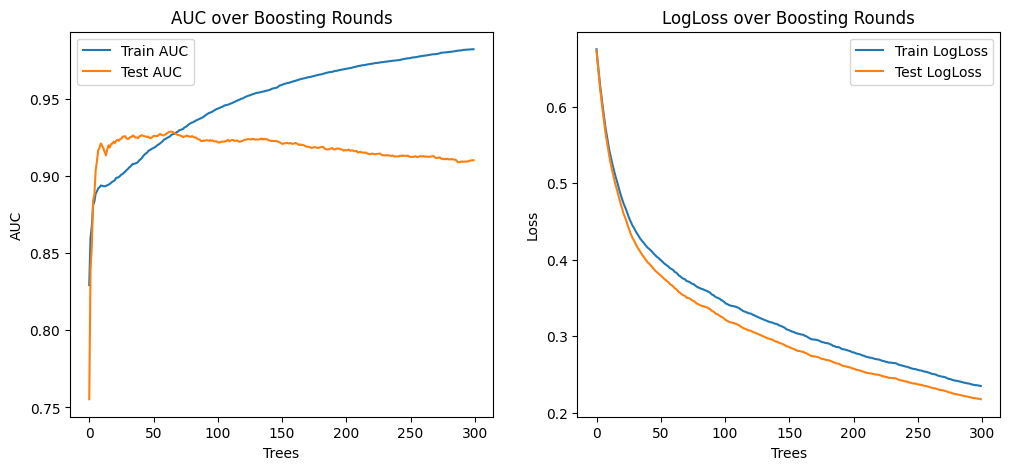

In [ ]:
# VISUALIZATION OF AUC AND LOGLOSS (via matplotlib)

plt.figure(figsize=(12,5)) # 1-figure canvas

plt.subplot(1,2,1) # 1 row, 2 columns, 1st plot
plt.plot(train_auc, label="Train AUC") # new line
plt.plot(test_auc, label="Test AUC") # new line
plt.title("AUC over Boosting Rounds") # labels
plt.xlabel("Trees")
plt.ylabel("AUC")
plt.legend() # show key

plt.subplot(1,2,2) # 1 row, 2 columns, 2nd plot
plt.plot(train_loss, label="Train LogLoss") # new line
plt.plot(test_loss, label="Test LogLoss") # new line
plt.title("LogLoss over Boosting Rounds") # labels
plt.xlabel("Trees")
plt.ylabel("Loss")
plt.legend() # show key

plt.show() # show plot

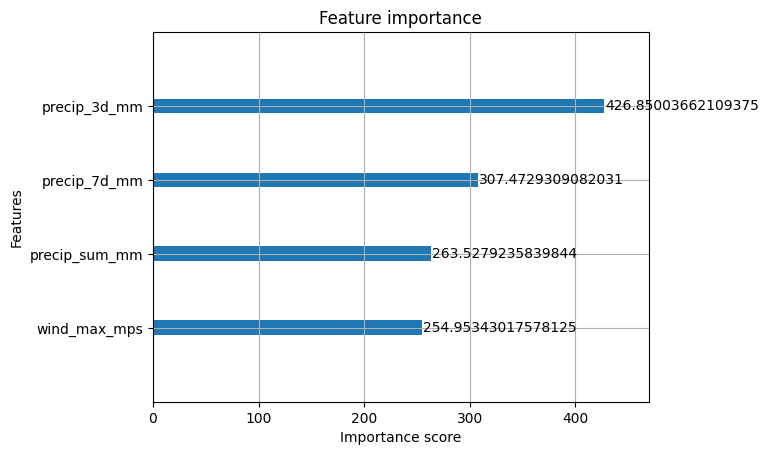

In [ ]:
# FEATURE IMPORTANCE ACCORDING TO GAIN
# Measures how much each feature improves splits across the data.
xgb.plot_importance(model, importance_type="gain") # =gain is due to the default order being different from pandas' ordering method (panads' is shown below)
plt.show()

In [ ]:
# FEATURE IMPORTANCE ACCORDING TO PANDAS
# Basically same as above, but not graphed + using pandas instead of xgb as a kind of cross-confirmation
# Extracts numeric feature importance values into a pandas series so they can be sorted and printed directly.
importance = pd.Series(model.feature_importances_, index=feature_cols)
print(importance.sort_values(ascending=False)) # same order as the graph above(high to low)

precip_3d_mm     0.340716
precip_7d_mm     0.245428
precip_sum_mm    0.210350
wind_max_mps     0.203506
dtype: float32


In [ ]:
# AUC SCORE
probs = model.predict_proba(X_test)[:,1] # returns the predicted probability of outage for each test row, sliced at second column (class 1, outage)
auc = roc_auc_score(y_test, probs) # extracting the AUC score
print("AUC:", auc)

AUC: 0.9102818647530376


In [ ]:
# ACCURACY SCORE
preds = (probs > 0.5).astype(int) # convert probabilities into hard class predictions using a 0.5 threshold
accuracy = accuracy_score(y_test, preds) # then computing accuracy
print("Accuracy:", accuracy)

Accuracy: 0.8982344115286647


In [ ]:
# RECALL

# Computing recall with threshold at 0.30 instead of 0.50.
# (Lowering the threshold usually increases recall by labeling more cases as positive!)
preds = (probs > 0.30).astype(int)
recall = recall_score(y_test, preds) # extracting the recall score
print("Recall:", recall)

Recall: 0.8435374149659864


# Post-processing
Saving the model and exporting county risk JSON, FIPS-keyed JSON, and metrics JSON.

In [ ]:
# SAVE MODEL
# Saving the trained XGBoost model to the Drive as JSON so it can be reloaded without retraining.
model.save_model("xgb_outage_model.json")
print("Saved:")
print("- xgb_outage_model.json")

In [ ]:
# LOAD MODEL (used when sessions aren't continuous since Colab deletes it every time)
model = XGBClassifier()
model.load_model("xgb_outage_model.json")

In [ ]:
# TEST JSON PRODUCTION
# Turns model output into a format that could be used by my website.
# Not used for the final product, but a JSON is produced from the test set data.
# (This set is listed in the folder with a changed name, county_outage_risk_wa_test.)

# Predict on test set
test = test.copy() # new copy
test["outage_prob"] = model.predict_proba(test[feature_cols])[:, 1] # new column created from predicted probabilities

# Keep latest day only
latest_date = test["date"].max()
site_df = test[test["date"] == latest_date].copy()
site_df = site_df[site_df["state"] == "Washington"].copy() # filter to only Washington state

# Converting raw weather feature values into a readable explanation (aforementioned "reason")
def risk_reason(row):

    wind = row["wind_max_mps"]
    p1 = row["precip_sum_mm"]
    p3 = row["precip_3d_mm"]
    p7 = row["precip_7d_mm"]

    if wind >= 5 and p7 >= 8:
        return "wind + wet ground" # first checks if there is very strong wind + very large accumulation of precipitation

    # Dictionary where each explanation gets a scaled severity score
    # (Had to change the values a few times to make sure the values fall between the range)
    scores = {
        "gusty winds": wind / 5,
        "rain today": p1 / 3,
        "recent rain": p3 / 8,
        "wet ground": p7 / 12
    }

    return max(scores, key=scores.get) # return the dictionary key whose value is largest (determine main reason)

site_df["probability"] = site_df["outage_prob"].round(4)
site_df["reason"] = site_df.apply( # applies a function row by row
    lambda row: risk_reason(row) if row["outage_prob"] >= 0.20 else "",
    axis=1 # operate ACROSS columns for each row (would be applied vertically/in columns without)
)

# County-name keyed payload for website JS
predictions_by_county = {
    row["county"]: {
        "probability": float(row["probability"]),
        "reason": row["reason"]
    }
    for _, row in site_df.iterrows() # build nested JSON structure in a compact loop
}

# Metrics output
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.50).astype(int)

metrics = {
    "auc": round(float(roc_auc_score(y_test, probs)), 3), # some rounding for clean output
    "recall": round(float(recall_score(y_test, preds)), 3),
    "accuracy": round(float(accuracy_score(y_test, preds)), 3),
}

payload = {
    "generated_at": str(pd.to_datetime(latest_date).date()),
    "metrics": metrics,
    "predictions": predictions_by_county
}

with open("county_outage_risk_wa.json", "w") as f:
    json.dump(payload, f, indent=2) # outputs formatted JSON!

print("Saved:")
print("- county_outage_risk_wa.json")

Saved:
- county_outage_risk_wa.json


In [ ]:
print(site_df["state"].unique()) # confirm that the final export is only for Washington state
print(len(site_df)) # show how many county rows remain

['Washington']
32


In [ ]:
# Checking that all of the WA counties exist
# They do not, since there should be 39. For example, Chelan doesn't exist here for some reason,
# but this issue resolved itself in the final export with current data instead of test data.
# It is possible some of these were filtered off at the top when building the test set.
wa_counties = sorted(test.loc[test["state"] == "Washington", "county"].dropna().unique())
print(len(wa_counties))
print(wa_counties)

32
['Adams', 'Asotin', 'Benton', 'Clallam', 'Clark', 'Columbia', 'Cowlitz', 'Douglas', 'Ferry', 'Garfield', 'Grant', 'Island', 'Jefferson', 'King', 'Kitsap', 'Kittitas', 'Lewis', 'Lincoln', 'Mason', 'Okanogan', 'Pend Oreille', 'Pierce', 'San Juan', 'Skagit', 'Snohomish', 'Spokane', 'Stevens', 'Thurston', 'Walla Walla', 'Whatcom', 'Whitman', 'Yakima']
